In [2]:
import sys
from pathlib import Path
sys.path.append('../')

from matching_clustering.utils import LapOT, lot_quad
from matching_clustering.precompute_helpers import cost_matrix_c
from __future__ import annotations
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import pairwise_distances
from scipy.sparse import csgraph
from sklearn.metrics.pairwise import rbf_kernel


### Example: 1D Gaussian Mixture
#### The data:

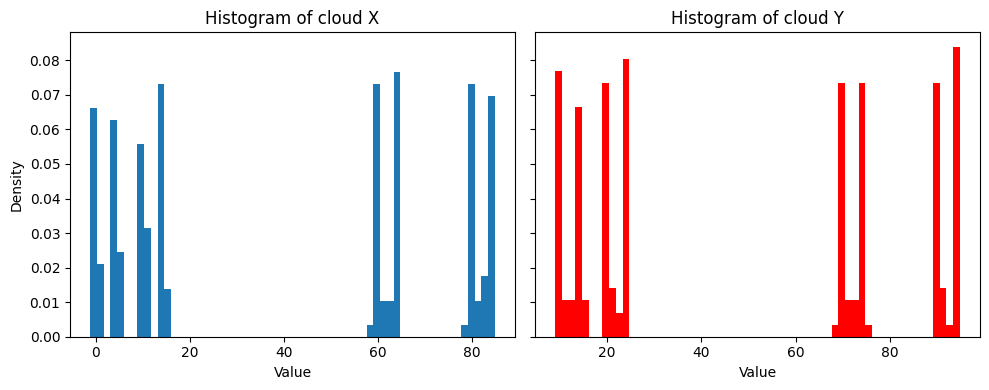

In [4]:
rng = np.random.default_rng(0)

n_groups = 4
samples_per_group = 25

# Gaussian parameters for X
means_X = np.array([0.0, 4.0, 10.0, 14.0, 60.0, 64.0, 80.0, 84.0 ])
stds_X  = np.array([0.5 for i in range(8)])

# Gaussian parameters for Y (different)
means_Y = np.array([10.0, 14.0, 20.0, 24.0, 70.0, 74.0, 90.0, 94.0])
stds_Y  = np.array([0.5 for i in range(8)])

# Generate point clouds
X = np.vstack([
    rng.normal(mu, sigma, size=(samples_per_group, 1))
    for mu, sigma in zip(means_X, stds_X)
])

Y = np.vstack([
    rng.normal(mu, sigma, size=(samples_per_group, 1))
    for mu, sigma in zip(means_Y, stds_Y)
])


# ---- Plot histograms side by side and save figure ----

# Path to save the figure
base_dir = Path.cwd()  # instead of __file__
output_path = base_dir / "Figures" / "LapLOT_1D_example_data.pdf"
output_path.parent.mkdir(parents=True, exist_ok=True)



fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].hist(X.flatten(), bins=60, density=True)
axes[0].set_title("Histogram of cloud X")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Density")

axes[1].hist(Y.flatten(), bins=60, density=True, color='red')
axes[1].set_title("Histogram of cloud Y")
axes[1].set_xlabel("Value")

plt.tight_layout()
plt.savefig(output_path, bbox_inches="tight")
plt.show()


#### Pre-compute the matrices $L_X, L_Y, C$

In [ ]:
# calculate RBF kernel similarity matrices for X and Y 
W_X = rbf_kernel(X, gamma=1/(0.5**2*2))
W_Y = rbf_kernel(Y, gamma=1/(0.5**2*2))

# Calculate the un-normalized graph Laplacians for X and Y
L_X = csgraph.laplacian(W_X, normed=False)
L_Y = csgraph.laplacian(W_Y, normed=False)

# Calculate the full distance matrix
pairwise_distances_X = pairwise_distances(X, metric='euclidean')
pairwise_distances_Y = pairwise_distances(Y, metric='euclidean')

# Control the sigma parameter for the marginals (smaller sigma means more local neighborhood, larger sigma means more global)
W_X_match = rbf_kernel(X, gamma=1/(0.077**2*2))
np.fill_diagonal(W_X_match, 0)
W_Y_match = rbf_kernel(Y, gamma=1/(0.077**2*2))
np.fill_diagonal(W_Y_match, 0)

# Calculate the degree based marginals for X and Y
a = W_X_match.sum(axis=1) / W_X_match.sum()
b = W_Y_match.sum(axis=1) / W_Y_match.sum()

# Calculate the cost matrix C for LapOT using the pairwise distance matrices and the marginals a and b
C = cost_matrix_c(pairwise_distances_X, pairwise_distances_Y, a=a, b=b)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 4072 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 40000 out of 40000 | elapsed:    0.8s finished


#### Solve $\text{LapOT}$ as reference and $\text{LapLOT}$ for various ranks $r$ and visually compare the results
#### NOTE: 
#### The current initialization of LapLOT is random, and since the optimization problem is not convex, the optimal solution could vary. 


Implement fixed point algorithm
max of entropy term :-0.8869738424116864 
 max of main term: 1.614656937943127
max of entropy term :-0.8903915404817866 
 max of main term: 1.6178149592851356
max of entropy term :-0.8899061390655091 
 max of main term: 1.6173145834242326
max of entropy term :-0.8900251752699493 
 max of main term: 1.6174317762841486
max of entropy term :-0.8899906707152369 
 max of main term: 1.617396902777821
max of entropy term :-0.8900028277674621 
 max of main term: 1.6174089754868215
max of entropy term :-0.8899980451694649 
 max of main term: 1.617404160802553
max of entropy term :-0.8900001677267882 
 max of main term: 1.6174062778695715


/Users/gabrielsamberg/Desktop/Research/Matching-Clustering/.venv/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:666: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


max of entropy term :-0.8899991579804807 
 max of main term: 1.6174052631091738
max of entropy term :-0.8899996724071088 
 max of main term: 1.6174057776472943
Terminated after 9 iterations (objective increased)
Iteration 0, error: 9.736078282821659e-10
Objective 6.18670521084074
Iteration 10, error: 5.088954487027934e-10
Objective 6.180765591599032
Iteration 20, error: 5.078989456954396e-10
Objective 6.1749844964742495
Iteration 30, error: 5.041375151694751e-10
Objective 6.167467853283925
Iteration 40, error: 4.973953128710734e-10
Objective 6.155862577419782
Iteration 50, error: 4.873522344374582e-10
Objective 6.13676143373926
Iteration 60, error: 4.736461988871504e-10
Objective 6.105102377364243
Iteration 70, error: 4.559968646579045e-10
Objective 6.053777343438877
Iteration 80, error: 4.303743095624514e-10
Objective 5.974237208181968
Iteration 90, error: 3.9823101370230396e-10
Objective 5.860010720275951
Iteration 100, error: 3.6563424862899096e-10
Objective 5.708360724299757
Iterat

/Users/gabrielsamberg/Desktop/Research/Matching-Clustering/.venv/lib/python3.12/site-packages/ot/lowrank.py:310: UserWarning: Dykstra did not converge. You might want to increase the number of iterations `numItermax` 
  warnings.warn(


Iteration 430, error: 1.448432641892968e-09
Objective 1.9310906382503137
Iteration 440, error: 3.072976436143495e-09
Objective 1.9125500180301822
Iteration 450, error: 5.194048954411326e-09
Objective 1.8943462464312417
Iteration 460, error: 7.653142973728818e-09
Objective 1.876497177986428
Iteration 470, error: 1.0569459327809479e-08
Objective 1.8590970306081118
Iteration 480, error: 1.423624228044449e-08
Objective 1.8423213583841433
Iteration 490, error: 1.8917635311334484e-08
Objective 1.8264207306263291
Iteration 500, error: 2.4778515610425696e-08
Objective 1.811698413617147
Iteration 510, error: 3.189728002481681e-08
Objective 1.7984711998274647
Iteration 520, error: 4.024638447992334e-08
Objective 1.787016795434231
Iteration 530, error: 4.960813079903504e-08
Objective 1.7775160054826704
Iteration 540, error: 5.948992249651226e-08
Objective 1.7700041685025325
Iteration 550, error: 6.916169627021613e-08
Objective 1.7643518871033406
Iteration 560, error: 7.787728369605763e-08
Objecti

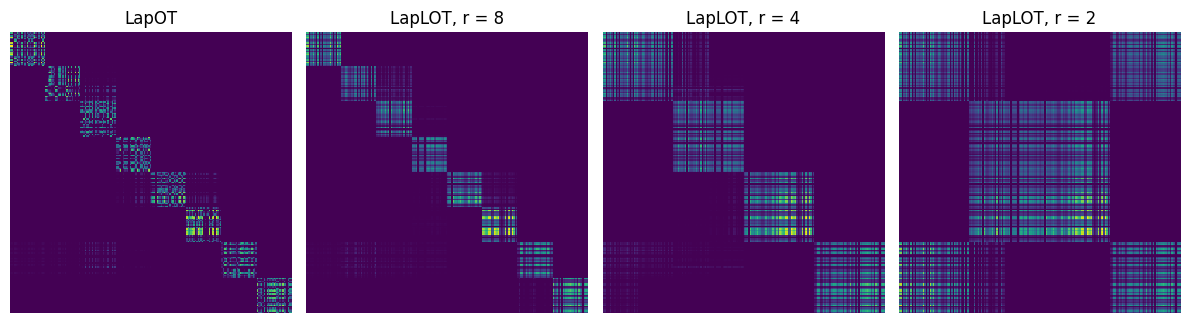

In [9]:
prob = LapOT(L_X, L_Y, C, l=0.1, l_x=1, l_y=1, w=a, v=b)
pi_fp = prob.solve(method='fp', verbose=False)

pi_low_rank_2 = lot_quad(C, L_X, L_Y, a, b, r=2, l=0.1, l_x=1, l_y=1, alpha=1e-5, gamma=1)
pi_low_rank_4 = lot_quad(C, L_X, L_Y, a, b, r=4, l=0.1, l_x=1, l_y=1, alpha=1e-5, gamma=1)
pi_low_rank_8 = lot_quad(C, L_X, L_Y, a, b, r=8, l=0.1, l_x=1, l_y=1, alpha=1e-5, gamma=1)

# Save path for the figure
base_dir = Path.cwd()  # instead of __file__
output_path = base_dir / "Figures" / "LapLOT_1D_example_results.pdf"
output_path.parent.mkdir(parents=True, exist_ok=True)

# Plot the matrices side by side
matrices = [pi_fp, pi_low_rank_8 ,pi_low_rank_4, pi_low_rank_2]
titles = ['LapOT', 'LapLOT, r = 8', 'LapLOT, r = 4','LapLOT, r = 2' ]
fig, axes = plt.subplots(1, 4, figsize=(12, 4))  # 1 row, 3 columns
for i, ax in enumerate(axes):
    im = ax.imshow(matrices[i], cmap='viridis', interpolation='nearest')
    ax.set_title(titles[i])
    ax.axis('off')  # optional: hide axis ticks
plt.tight_layout()
plt.savefig(output_path, bbox_inches="tight")    